In [ ]:
import pandas as pd
import numpy as np
import os
import re
import glob
import matplotlib.pyplot as plt

# 1. CONCATENATE TYPES OF OBJECTS

(Space Stations, Sattelites, Debris, Analyst)

In [18]:
# READ FILES
space_station_df = pd.read_csv("DATASETS_SATTELITES/celestrack/Space_Station/space_station.csv")
sattelites_df = pd.read_csv("DATASETS_SATTELITES/celestrack/Sattelites/celestrack_active_sattelites.csv")
analyst_df = pd.read_csv("DATASETS_SATTELITES/celestrack/Analyst/analyst_sattelites.csv")
cosmos_1408_deb_df = pd.read_csv("DATASETS_SATTELITES/celestrack/Debris/cosmos_1408.csv")
cosmos_2251_deb_df = pd.read_csv("DATASETS_SATTELITES/celestrack/Debris/cosmos_2251.csv")
fengyun_1c_deb_df = pd.read_csv("DATASETS_SATTELITES/celestrack/Debris/fengyun_1c.csv")
iridium_33_deb_df = pd.read_csv("DATASETS_SATTELITES/celestrack/Debris/iridium_33.csv")

# DEFINE LISTS TO HELP WITH DATASET CREATION
df_names = ["space_station_df", "sattelites_df", "analyst_df", "cosmos_1408_deb_df", "cosmos_2251_deb_df", "fengyun_1c_deb_df", "iridium_33_deb_df"]
df_list = [space_station_df, sattelites_df, analyst_df, cosmos_1408_deb_df, cosmos_2251_deb_df, fengyun_1c_deb_df, iridium_33_deb_df]
df_types = ["Space Station", "Sattelite", "Analyst", "Debris", "Debris", "Debris", "Debris"]

# COUNT AND ADD NEW COLUMN (OBJECT TYPE)
total_objects = 0
print("DATASETS SIZES:")
for df, name, type in zip(df_list, df_names, df_types):
    cur_objects = len(df.index)
    total_objects += cur_objects
    df.insert(2, 'OBJECT_TYPE', type)   # third column
    print(f"{name:20}: {cur_objects}")

print("\nTOTAL OBJECTS:", total_objects)

DATASETS SIZES:
space_station_df    : 34
sattelites_df       : 14408
analyst_df          : 444
cosmos_1408_deb_df  : 4
cosmos_2251_deb_df  : 581
fengyun_1c_deb_df   : 1844
iridium_33_deb_df   : 109

TOTAL OBJECTS: 17424


In [19]:
# CONCATENATE DATA
total_df = pd.concat([space_station_df, sattelites_df, analyst_df, cosmos_1408_deb_df, cosmos_2251_deb_df, fengyun_1c_deb_df, iridium_33_deb_df])

### Check duplicates

In [20]:
duplicados = total_df[total_df["NORAD_CAT_ID"].duplicated()]
len(duplicados)

30

In [21]:
# 1. Filtra mantendo TODAS as instâncias dos IDs duplicados
# 2. Ordena por ID para que os gémeos fiquem colados um ao outro
duplicados_completos = total_df[total_df.duplicated(subset="NORAD_CAT_ID", keep=False)].sort_values("NORAD_CAT_ID")

# 3. Imprime sem truncar as linhas (para veres a lista toda)
import pandas as pd
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(duplicados_completos[["NORAD_CAT_ID", "OBJECT_NAME", "OBJECT_TYPE"]])

       NORAD_CAT_ID      OBJECT_NAME    OBJECT_TYPE
0             25544      ISS (ZARYA)  Space Station
60            25544      ISS (ZARYA)      Sattelite
2267          48274     CSS (TIANHE)      Sattelite
2             48274     CSS (TIANHE)  Space Station
3             49044      ISS (NAUKA)  Space Station
2603          49044      ISS (NAUKA)      Sattelite
3943          53239    CSS (WENTIAN)      Sattelite
5             53239    CSS (WENTIAN)  Space Station
6             54216   CSS (MENGTIAN)  Space Station
4610          54216   CSS (MENGTIAN)      Sattelite
11629         64751   PROGRESS-MS 31      Sattelite
7             64751   PROGRESS-MS 31  Space Station
8             64786       TIANZHOU-9  Space Station
11660         64786       TIANZHOU-9      Sattelite
12364         65586   PROGRESS-MS 32      Sattelite
9             65586   PROGRESS-MS 32  Space Station
10            65616     CYGNUS NG-23  Space Station
12391         65616     CYGNUS NG-23      Sattelite
12488       

We notice the duplicates are characterizes as both sattelite and space station. 
For the porpuse of this project, we decided to characterize them as Space Station, since that object type is more "special".

In [22]:
# 1. Identificamos quais são os IDs que aparecem mais de uma vez
ids_duplicados = total_df[total_df.duplicated('NORAD_CAT_ID', keep=False)]['NORAD_CAT_ID'].unique()

# 2. Mantemos apenas as linhas que:
# (NÃO têm um ID duplicado) OU (têm ID duplicado mas o tipo NÃO é 'Sattelite')
total_df = total_df[~(total_df['NORAD_CAT_ID'].isin(ids_duplicados) & (total_df['OBJECT_TYPE'] == 'Sattelite'))]

### Check duplicates again

In [23]:
len(total_df[total_df.duplicated('NORAD_CAT_ID')])

0

# 2. Check files

In [24]:
# FOLDERS
base_folder = "DATASETS_SATTELITES/celestrack"

weather_folder = f"{base_folder}/Weather"
communication_folder = f"{base_folder}/Communication"
brightest_folder = f"{base_folder}/Brightest"
earth_res_folder = f"{base_folder}/Earth_Resources"
misc_folder = f"{base_folder}/Miscellaneous"
nav_folder = f"{base_folder}/Navigation"
scientific_folder = f"{base_folder}/Scientific"

folder_list = [weather_folder, communication_folder, brightest_folder, earth_res_folder, misc_folder, nav_folder, scientific_folder]
filter_list = ["WEATHER", "COMMUNICATION", "BRIGHTEST", "EARTH_RESOURCES", "MISCELLANEOUS", "NAVIGATION", "SCIENTIFIC"]


Check if there are values on the datasets, not present in their respective filter all.csv file

In [25]:
for folder, category in zip(folder_list, filter_list):
    if os.path.exists(folder):
        # Criamos uma lista de todos os caminhos a verificar (a pasta raiz + subpastas)
        paths_to_check = [folder]
        
        # Se for Communication, adicionamos explicitamente as subpastas à lista
        if category == "COMMUNICATION":
            subfolders = [f.path for f in os.scandir(folder) if f.is_dir()]
            paths_to_check.extend(subfolders)

        for current_path in paths_to_check:
            files = os.listdir(current_path)
            
            # 1. Tentar encontrar o ficheiro "ALL" nesta pasta específica
            all_file = [f for f in files if "all" in f.lower() and f.endswith(".csv")]
            
            if not all_file:
                # Se não há "ALL", não temos base de comparação para esta pasta
                folder_name = os.path.basename(current_path)
                print(f"⚠️ Aviso: Não foi encontrado ficheiro 'ALL' em {category} -> {folder_name}")
                print("-"*30)
                continue

            all_path = os.path.join(current_path, all_file[0])
            
            if os.path.getsize(all_path) > 0:
                df_all = pd.read_csv(all_path)
                ids_all = set(df_all['NORAD_CAT_ID'].unique())
            else:
                print(f"❌ Erro: O ficheiro mestre {all_file[0]} está vazio.")
                continue

            # 2. Comparar os outros ficheiros desta pasta contra o "ALL"
            for filename in files:
                if filename.endswith(".csv") and "all" not in filename.lower():
                    file_path = os.path.join(current_path, filename)
                    
                    if os.path.getsize(file_path) > 0:
                        try:
                            this_df = pd.read_csv(file_path)
                            ids_specific = set(this_df['NORAD_CAT_ID'].unique())
                            
                            orphans = ids_specific - ids_all
                            
                            if orphans:
                                # Usamos o nome da pasta atual para o print ser claro
                                loc = os.path.basename(current_path)
                                print(f"❗ Inconsistência em {category} ({loc}) -> {filename}:")
                                print(f"   {len(orphans)} IDs presentes aqui não aparecem no ficheiro 'ALL'.")
                                print("-" * 30)
                        except Exception as e:
                            print(f"❌ Erro ao ler {filename}: {e}")

❗ Inconsistência em WEATHER (Weather) -> goes.csv:
   13 IDs presentes aqui não aparecem no ficheiro 'ALL'.
------------------------------
❗ Inconsistência em WEATHER (Weather) -> noaa.csv:
   20 IDs presentes aqui não aparecem no ficheiro 'ALL'.
------------------------------
⚠️ Aviso: Não foi encontrado ficheiro 'ALL' em COMMUNICATION -> Communication
------------------------------
❗ Inconsistência em COMMUNICATION (Active_Geosynchronous) -> geo_protected_zone.csv:
   331 IDs presentes aqui não aparecem no ficheiro 'ALL'.
------------------------------
❗ Inconsistência em COMMUNICATION (Active_Geosynchronous) -> geo_protected_zone_plus.csv:
   1183 IDs presentes aqui não aparecem no ficheiro 'ALL'.
------------------------------
⚠️ Aviso: Não foi encontrado ficheiro 'ALL' em COMMUNICATION -> Constellations
------------------------------
❗ Inconsistência em EARTH_RESOURCES (Earth_Resources) -> argos.csv:
   29 IDs presentes aqui não aparecem no ficheiro 'ALL'.
------------------------

Check if in each folder, there are objects simultaneous in differente filter types

For example: sattelite being both education and engineering

(Comunication folder not included)

In [26]:
for folder, category in zip(folder_list, filter_list):
    if os.path.exists(folder):
        files = [f for f in os.listdir(folder) if f.endswith(".csv") and "all" not in f.lower()]
        
        # Dicionário para mapear: {ID_do_satelite: [lista_de_ficheiros_onde_aparece]}
        seen_ids = {}

        print(f"--- Verificando duplicados internos em: {category} ---")
        
        for filename in files:
            file_path = os.path.join(folder, filename)
            
            if os.path.getsize(file_path) > 0:
                try:
                    this_df = pd.read_csv(file_path)
                    ids_in_file = this_df['OBJECT_ID'].unique()
                    
                    for sat_id in ids_in_file:
                        if sat_id in seen_ids:
                            seen_ids[sat_id].append(filename)
                        else:
                            seen_ids[sat_id] = [filename]
                            
                except Exception as e:
                    print(f"❌ Erro ao ler {filename}: {e}")

        # Após ler todos os ficheiros da pasta, reportar quem aparece em mais de um
        duplicates_found = False
        for sat_id, filenames in seen_ids.items():
            if len(filenames) > 1:
                duplicates_found = True
                print(f"🔍 Satélite {sat_id} repetido em: {', '.join(filenames)}")
        
        if not duplicates_found:
            print("✅ Nenhum satélite repetido entre os ficheiros específicos.")
        
        print("-" * 40)

--- Verificando duplicados internos em: WEATHER ---
✅ Nenhum satélite repetido entre os ficheiros específicos.
----------------------------------------
--- Verificando duplicados internos em: COMMUNICATION ---
✅ Nenhum satélite repetido entre os ficheiros específicos.
----------------------------------------
--- Verificando duplicados internos em: BRIGHTEST ---
✅ Nenhum satélite repetido entre os ficheiros específicos.
----------------------------------------
--- Verificando duplicados internos em: EARTH_RESOURCES ---
🔍 Satélite 2012-049A repetido em: argos.csv, sarsat.csv
----------------------------------------
--- Verificando duplicados internos em: MISCELLANEOUS ---
✅ Nenhum satélite repetido entre os ficheiros específicos.
----------------------------------------
--- Verificando duplicados internos em: NAVIGATION ---
🔍 Satélite 2018-085A repetido em: augmentation_system.csv, beidou.csv
🔍 Satélite 2020-017A repetido em: augmentation_system.csv, beidou.csv
🔍 Satélite 2020-040A repet

Comunication folder

In [27]:
from itertools import combinations

base_comm_path = "DATASETS_SATTELITES/celestrack/Communication"
subfolders = ["Active_Geosynchronous", "Constellations"]

for sub in subfolders:
    sub_path = os.path.join(base_comm_path, sub)
    if not os.path.exists(sub_path):
        continue

    print(f"\n📂 SOBREPOSIÇÃO EM: {sub}")
    
    # 1. Carregar os IDs de cada ficheiro num dicionário de sets
    file_data = {}
    files = [f for f in os.listdir(sub_path) if f.endswith(".csv") and "all" not in f.lower()]
    
    for filename in files:
        df = pd.read_csv(os.path.join(sub_path, filename))
        file_data[filename] = set(df['NORAD_CAT_ID'].unique())

    # 2. Comparar todos os pares possíveis de ficheiros (Combinações)
    found_any = False
    for f1, f2 in combinations(file_data.keys(), 2):
        # Interseção entre os dois conjuntos de IDs
        common = file_data[f1].intersection(file_data[f2])
        
        if len(common) > 0:
            found_any = True
            print(f"🔗 {f1:21} <---> {f2}: {len(common)} satélites em comum")

    if not found_any:
        print("✅ Tudo limpo: Nenhum ficheiro partilha satélites nesta pasta.")
    print("-" * 50)


📂 SOBREPOSIÇÃO EM: Active_Geosynchronous
🔗 geo_protected_zone.csv <---> geo_protected_zone_plus.csv: 872 satélites em comum
--------------------------------------------------

📂 SOBREPOSIÇÃO EM: Constellations
🔗 amateur_radio.csv     <---> experimental_comm.csv: 2 satélites em comum
🔗 amateur_radio.csv     <---> other_comm.csv: 1 satélites em comum
🔗 amateur_radio.csv     <---> satnogs.csv: 71 satélites em comum
🔗 experimental_comm.csv <---> other_comm.csv: 1 satélites em comum
🔗 experimental_comm.csv <---> satnogs.csv: 5 satélites em comum
🔗 iridium_next.csv      <---> satnogs.csv: 3 satélites em comum
🔗 orbcomm.csv           <---> satnogs.csv: 8 satélites em comum
🔗 other_comm.csv        <---> satnogs.csv: 1 satélites em comum
🔗 other_comm.csv        <---> ses.csv: 23 satélites em comum
🔗 other_comm.csv        <---> telesat.csv: 1 satélites em comum
🔗 satnogs.csv           <---> starlink.csv: 6 satélites em comum
--------------------------------------------------


# 3. Inactive Sattelites

Here we add the sattelites in the files, that don't show on "celestrack_active_sattelites.csv".

The Objects with "DEB" in their name, were changed to "Debris" in columns "OBJECT_TYPE".

And the ones with "R/B", were changed to "Rocket body".

Debris, are considered "False" in colummn "ACTIVE".

And, the existing Rocket bodies in "celestrack_active_sattelites.csv" are considered True, while the rest is False.

In [28]:
# 1. Guardar os IDs que já tens no teu dataframe atual
ids_existentes = set(total_df['NORAD_CAT_ID'].unique())

# 2. Preparar as regras da coluna ACTIVE para os dados que JÁ ESTÃO no total_df
# Se a coluna não existir, inserimos na posição 3 (tudo a False inicialmente)
if 'ACTIVE' not in total_df.columns:
    total_df.insert(3, 'ACTIVE', False)
else:
    total_df['ACTIVE'] = False

# Space Station e Sattelite a True
total_df.loc[total_df['OBJECT_TYPE'].isin(['Space Station', 'Sattelite']), 'ACTIVE'] = True
# Debris e Analyst a False
total_df.loc[total_df['OBJECT_TYPE'].isin(['Debris', 'Analyst']), 'ACTIVE'] = False

# 3. Procurar os "órfãos" nos ficheiros das pastas
base_folder = "DATASETS_SATTELITES/celestrack"
todos_ficheiros = glob.glob(f"{base_folder}/**/*.csv", recursive=True)

novas_linhas = []
print("🔍 À procura de satélites em falta nas pastas...")

for ficheiro in todos_ficheiros:
    if os.path.getsize(ficheiro) > 0:
        try:
            df_temp = pd.read_csv(ficheiro)
            
            # Garantir que usamos a coluna certa
            id_col = 'NORAD_CAT_ID' if 'NORAD_CAT_ID' in df_temp.columns else 'OBJECT_ID'
            
            if id_col in df_temp.columns:
                # Filtrar apenas os que ainda não estão no dataset
                orfãos = df_temp[~df_temp[id_col].isin(ids_existentes)].copy()
                
                if not orfãos.empty:
                    # Renomear coluna de ID se necessário
                    if id_col == 'OBJECT_ID':
                        orfãos = orfãos.rename(columns={'OBJECT_ID': 'NORAD_CAT_ID'})
                    
                    # Colocamos como satélite inativo por defeito
                    orfãos['OBJECT_TYPE'] = 'Sattelite'
                    orfãos['ACTIVE'] = False
                    
                    novas_linhas.append(orfãos)
                    
                    # Atualizar o set
                    ids_existentes.update(orfãos['NORAD_CAT_ID'].unique())
                    
        except Exception as e:
            pass

# 4. Juntar os novos satélites ao teu total_df
if novas_linhas:
    df_novos = pd.concat(novas_linhas, ignore_index=True)
    total_df = pd.concat([total_df, df_novos], ignore_index=True)
    print(f"✅ Foram adicionados {len(df_novos)} novos satélites inativos.")
else:
    print("✅ Não faltava nenhum satélite.")

# 5. Garantir que não há duplicados
total_df = total_df.drop_duplicates(subset='NORAD_CAT_ID', keep='first')

# -------------------------------------------------------------------
# 6. LIMPEZA GLOBAL BASEADA NOS NOMES
# -------------------------------------------------------------------
print("🧹 A aplicar limpeza definitiva para Rocket Bodies e Debris...")

# 1. Identificar corpos de foguetões (R/B)
mask_rb = total_df['OBJECT_NAME'].str.contains(' R/B|ROCKET BODY', na=False, case=False)

# Mudamos apenas a categoria para saberes o que são!
total_df.loc[mask_rb, 'OBJECT_TYPE'] = 'Rocket Body'

# 2. Identificar lixo espacial e fragmentos (DEB)
mask_deb = total_df['OBJECT_NAME'].str.contains(' DEB|DEBRIS', na=False, case=False)

# Aqui sim, mudamos a categoria E forçamos a False (porque lixo não emite sinal)
total_df.loc[mask_deb, 'OBJECT_TYPE'] = 'Debris'
total_df.loc[mask_deb, 'ACTIVE'] = False
# -------------------------------------------------------------------

# Mostrar o resumo da tua nova coluna com a limpeza já aplicada
print("\n📊 Resumo Final da coluna ACTIVE por OBJECT_TYPE:")
print(total_df.groupby(['OBJECT_TYPE', 'ACTIVE']).size().reset_index(name='Contagem'))

🔍 À procura de satélites em falta nas pastas...
✅ Foram adicionados 1640 novos satélites inativos.
🧹 A aplicar limpeza definitiva para Rocket Bodies e Debris...

📊 Resumo Final da coluna ACTIVE por OBJECT_TYPE:
     OBJECT_TYPE  ACTIVE  Contagem
0        Analyst   False       444
1         Debris   False      2835
2    Rocket Body   False       504
3    Rocket Body    True         6
4      Sattelite   False       840
5      Sattelite    True     14372
6  Space Station    True        33


# 4. ADD METADATA

Weather, Communication, Brightest, Earth Resources, Miscellaneaour, Navigation, Scientific

In [29]:
# 1. Definir quais as pastas que recebem a coluna MESTRE (Agregadora)
# Juntei 'MISCELLANEOUS' porque pediste na mensagem anterior, mas podes tirar se não quiseres.
categorias_mestre = ['NAVIGATION', 'SCIENTIFIC', 'COMMUNICATION', 'MISCELLANEOUS']

for folder, category in zip(folder_list, filter_list):
    if os.path.exists(folder):
        
        # Passar a categoria principal para MAIÚSCULAS
        category = category.upper()
        
        # Verificar se esta pasta tem direito a uma coluna Mestre
        usa_mestre = category in categorias_mestre
        
        if usa_mestre and category not in total_df.columns:
            total_df[category] = False
            
        for root, dirs, files in os.walk(folder):
            for filename in files:
                if filename.endswith(".csv"):
                    
                    # 2. LIMPEZA DO NOME DA COLUNA
                    # Tira o .csv, tira o _all, substitui espaços por underscores e põe em MAIÚSCULAS
                    col_name = filename.lower().replace('.csv', '')
                    col_name = col_name.replace('_all', '').replace('-all', '') # Apanha variações
                    col_name = col_name.replace(' ', '_').upper()
                    
                    file_path = os.path.join(root, filename)
                    
                    try:
                        this_df = pd.read_csv(file_path)
                        id_col = 'NORAD_CAT_ID' if 'NORAD_CAT_ID' in this_df.columns else 'OBJECT_ID'
                        ids_on_csv = this_df[id_col].unique()
                        
                        # 3. Criar a coluna ESPECÍFICA (ex: WEATHER, BRIGHTEST, STARLINK)
                        if col_name not in total_df.columns:
                            total_df[col_name] = False
                        
                        # Marcar True para os satélites deste ficheiro
                        total_df.loc[total_df['NORAD_CAT_ID'].isin(ids_on_csv), col_name] = True
                        
                        # 4. Atualizar a coluna MESTRE (se aplicável a esta pasta)
                        if usa_mestre:
                            total_df.loc[total_df['NORAD_CAT_ID'].isin(ids_on_csv), category] = True

                    except Exception as e:
                        print(f"❌ Erro ao ler {filename}: {e}")
    else:
        print(f"⚠️ WARNING: Pasta não encontrada - {folder}")

print(f"✅ Concluído! Nomes formatados e colunas mestre aplicadas seletivamente.")

✅ Concluído! Nomes formatados e colunas mestre aplicadas seletivamente.


In [30]:
teste_satelite = total_df.loc[total_df["NORAD_CAT_ID"] == 6920]
print(teste_satelite)

      OBJECT_NAME  OBJECT_ID OBJECT_TYPE  ACTIVE                       EPOCH  \
19021      NOAA 3  1973-086A   Sattelite   False  2026-03-01T00:44:26.747232   

       MEAN_MOTION  ECCENTRICITY  INCLINATION  RA_OF_ASC_NODE  \
19021    12.403915      0.000621      102.291         72.9251   

       ARG_OF_PERICENTER  ...  GLONASS_OPERATIONAL   GNSS GPS_OPERATIONAL  \
19021           325.4223  ...                False  False           False   

        NNSS  RUSSIAN_LEO_NAVIGATION  SCIENTIFIC  EDUCATION  ENGINEERING  \
19021  False                   False       False      False        False   

       GEODETIC  SPACE_EARTH  
19021     False        False  

[1 rows x 70 columns]


In [31]:
# SAVE FILE
total_df.to_csv("DATASETS_SATTELITES/dataset_concat.csv", index=False, )

# 5. Visualize

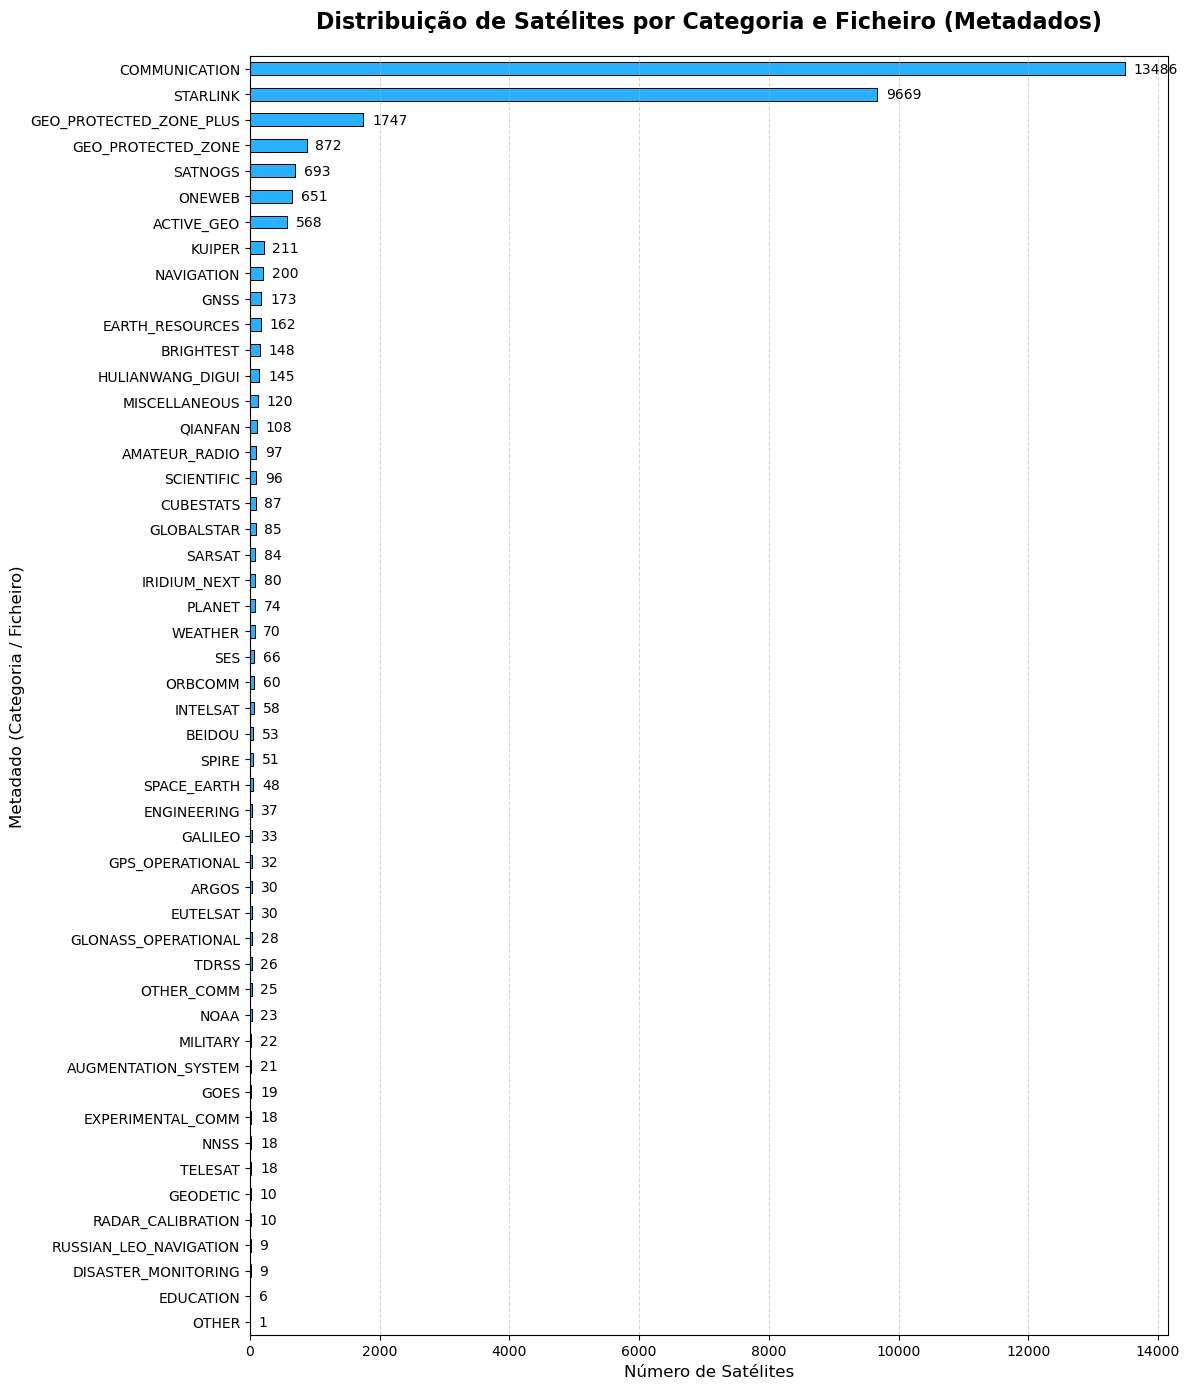

In [ ]:
# 1. Selecionar as colunas a contar
# Como definimos as colunas de metadados como booleanos (True/False), 
# podemos isolá-las facilmente filtrando pelo tipo de dados.
colunas_booleanas = total_df.select_dtypes(include=['bool']).columns.tolist()

# Vamos remover a coluna 'ACTIVE' se ela estiver na lista, 
# para o gráfico mostrar apenas as categorias e ficheiros
if 'ACTIVE' in colunas_booleanas:
    colunas_booleanas.remove('ACTIVE')

# 2. Contar quantos 'True' existem em cada coluna e ordenar
# O Pandas converte automaticamente True para 1 e False para 0 ao somar!
contagens = total_df[colunas_booleanas].sum().sort_values(ascending=True)

# Vamos ignorar as colunas que têm 0 satélites (se houver alguma) para limpar o gráfico
contagens = contagens[contagens > 0]

# 3. Desenhar o Gráfico
plt.figure(figsize=(12, 14)) # Altura grande para caberem todos os nomes confortavelmente
contagens.plot(kind='barh', color='#2ab0ff', edgecolor='black', linewidth=0.7)

# 4. Estilizar para ficar com aspeto profissional
plt.title('Distribuição de Satélites por Categoria e Ficheiro (Metadados)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Satélites', fontsize=12)
plt.ylabel('Metadado (Categoria / Ficheiro)', fontsize=12)

# Adicionar o número exato à frente de cada barra
for index, value in enumerate(contagens):
    plt.text(value + (max(contagens)*0.01), index, str(value), va='center', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Mostrar o gráfico
plt.show()

📊 Tabela de Comparação: Sem Metadados vs Total
--------------------------------------------------
               Sem Metadados  Total no Dataset
OBJECT_TYPE                                   
Sattelite               1857             15212
Debris                  2539              2835
Rocket Body                4               510
Analyst                  438               444
Space Station             29                33
--------------------------------------------------


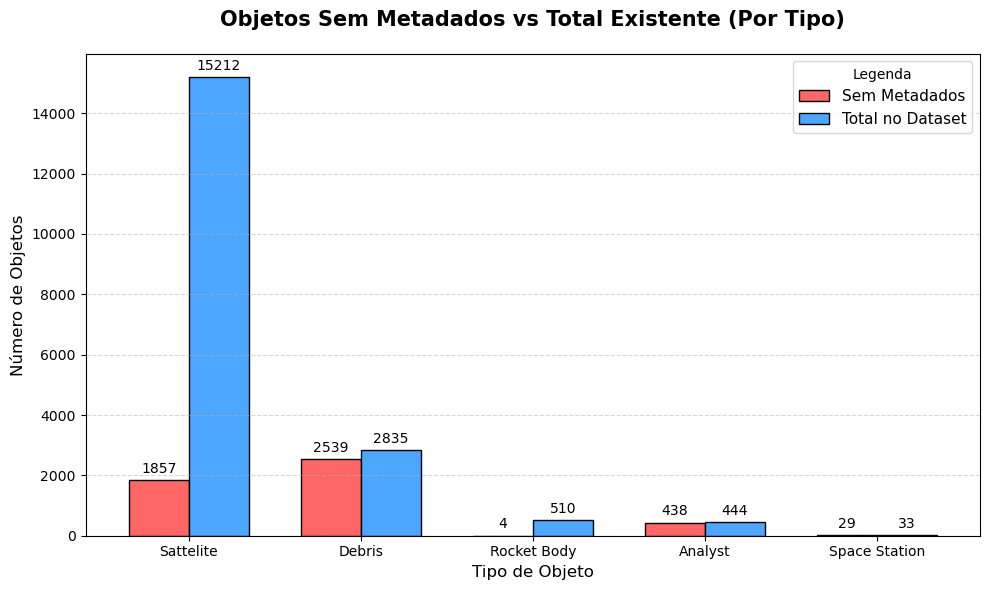

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Identificar as colunas de metadados
colunas_metadados = total_df.select_dtypes(include=['bool']).columns.tolist()
if 'ACTIVE' in colunas_metadados:
    colunas_metadados.remove('ACTIVE')

# 2. Encontrar os objetos que NÃO têm nenhum metadado associado
objetos_sem_metadados = total_df[~total_df[colunas_metadados].any(axis=1)]

# 3. Fazer as duas contagens separadas
contagem_sem = objetos_sem_metadados['OBJECT_TYPE'].value_counts()
contagem_total = total_df['OBJECT_TYPE'].value_counts()

# 4. Juntar as contagens num único DataFrame para facilitar a comparação
df_comparacao = pd.DataFrame({
    'Sem Metadados': contagem_sem,
    'Total no Dataset': contagem_total
}).fillna(0).astype(int) # Preenche os buracos com 0 caso algum tipo não tenha órfãos

# Ordenar pelo Total para o gráfico ficar com uma escadinha lógica
df_comparacao = df_comparacao.sort_values(by='Total no Dataset', ascending=False)

# Mostrar a tabela na consola
print("📊 Tabela de Comparação: Sem Metadados vs Total")
print("-" * 50)
print(df_comparacao)
print("-" * 50)

# 5. Criar o Gráfico de Barras Agrupadas (lado a lado)
ax = df_comparacao.plot(kind='bar', figsize=(10, 6), width=0.7, 
                        color=['#ff6666', '#4da6ff'], edgecolor='black')

plt.title('Objetos Sem Metadados vs Total Existente (Por Tipo)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tipo de Objeto', fontsize=12)
plt.ylabel('Número de Objetos', fontsize=12)
plt.xticks(rotation=0)

# Adicionar os números exatos em cima de cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0: # Não escreve o número "0" para manter o gráfico limpo
        ax.annotate(f'{int(altura)}',
                    (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom',
                    fontsize=10, xytext=(0, 3),
                    textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Legenda', fontsize=11)
plt.tight_layout()

# Mostrar o gráfico
plt.show()